# NOTEBOOK 6: Analyze KL Results
This notebook serves to take NB 5's csv of KL divergence information for worm runs and produce a simple diagram or set of diagrams. The diagram is a plot of the average KL scores of a groupe or troupe by day. 

## STUFF TO ADD:
- Add info about number of sample sizes per points  -- how many videos in each session, number of frames, etc.

## STEP 1: Define data-filling functions.
This cell defines the function to update KL CSV with experimental metadata:

**update_kl_with_log_info():**
- Reads existing KL divergence CSV
- Reads experimental log CSV with Run, Troupe, Day, Block information
- Matches videos by name
- Adds metadata columns to KL dataframe
- Saves updated CSV to new location

**Role in pipeline:**
Must be defined before master execution cell, but will be called from there with user-specified paths.

In [1]:
import pandas as pd
import numpy as np
import re
import os
from scipy import stats
import matplotlib.pyplot as plt
import pdb

def update_kl_with_log_info(kl_csv_path, log_csv_path, output_csv_path):
    """
    Update KL divergence CSV with experimental log information.
    
    Args:
        kl_csv_path: Path to KL divergence CSV file
        log_csv_path: Path to experimental log CSV file
        output_csv_path: Path where updated CSV should be saved
    
    Returns:
        Updated DataFrame with log information added
    """
    # Read both CSV files
    kl_df = pd.read_csv(kl_csv_path)
    log_df = pd.read_csv(log_csv_path)
    
    # Create a dictionary from log_df for easy lookup using Data_Folder
    log_dict = {}
    for _, row in log_df.iterrows():
        data_folder = row['Data_Folder']
        log_dict[data_folder] = {
            'Run': data_folder,  # ← Use Data_Folder as the Run value
            'Troupe': row['Troupe'],
            'Day': row['Day'],
            'Block': row['Block']
        }
    
    # Add log information to kl_df using 'session' column to match Data_Folder
    kl_df['Run'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Run', None))
    kl_df['Troupe'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Troupe', None))
    kl_df['Day'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Day', None))
    kl_df['Block'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Block', None))
    
    # Save updated dataframe
    kl_df.to_csv(output_csv_path, index=False)
    print(f"Updated KL CSV saved to: {output_csv_path}")
    print(f"Total rows: {len(kl_df)}")
    print(f"Rows with complete log info: {kl_df[['Run', 'Troupe', 'Day', 'Block']].notna().all(axis=1).sum()}")
    
    return kl_df

## STEP 2: Extract Worm Positions and Create Analysis DataFrame

This block contains two functions that prepare KL data for analysis:

In [2]:
def extract_worm_positions_from_session(session_data):
    """
    Extract worm positions for all videos in a session.
    Videos are sorted by the first coordinate in their region, and assigned W1, W2, etc.
    
    Args:
        session_data: DataFrame containing all videos from one session
    
    Returns:
        DataFrame with worm positions added
    """
    # Extract region from each video name and pair with the row
    video_regions = []
    
    for idx, row in session_data.iterrows():
        video_name = row['video']
        
        # Find region pattern (four numbers separated by underscores)
        region_pattern = r'regions_(\d+)_(\d+)_(\d+)_(\d+)'
        match = re.search(region_pattern, video_name)
        
        if match:
            x1, y1, x2, y2 = map(int, match.groups())
            video_regions.append((x1, y1, x2, y2, idx))
        else:
            print(f"Warning: Could not find region in {video_name}")
            video_regions.append((float('inf'), 0, 0, 0, idx))  # Put at end if no match
    
    # Sort by first coordinate (x1) to determine worm order
    sorted_regions = sorted(video_regions, key=lambda x: x[0])
    
    # Assign worm numbers based on sorted order
    session_data = session_data.copy()
    session_data['Worm'] = None
    for worm_num, (x1, y1, x2, y2, idx) in enumerate(sorted_regions, 1):
        session_data.loc[idx, 'Worm'] = worm_num
    
    return session_data


def create_worm_kl_dataframe_from_df(kl_df):
    """
    Create a dataframe with columns for each worm's KL values.
    Takes a dataframe directly instead of reading from CSV.
    
    Args:
        kl_df: DataFrame with KL divergence data
    
    Returns:
        DataFrame with columns: Run, Troupe, Day, Block, 
        W1_KL_ONOFF, W1_KL_OFFON, W1_KL_AVG, W2_KL_ONOFF, ...
    """

    #kl_df = pd.read_csv(kl_csv_path)

    feature_names = ['Areas', 'Area_percentages', 'Perimeters', 'Area_perimeter_ratios',
                    'Circularities', 'Hull_areas', 'Centroidxs', 'Centroidys', 
                    'Angles', 'Concavities']

    # Process each session to add worm positions
    processed_dfs = []
    for session_name, session_data in kl_df.groupby('session'):
        session_with_worms = extract_worm_positions_from_session(session_data)
        processed_dfs.append(session_with_worms)
    
    kl_df = pd.concat(processed_dfs, ignore_index=True)
    
    # Pivot the data to have one row per session with columns for each worm
    pivot_data = []
    
    for session_name, session_data in kl_df.groupby('session'):
        # Get metadata (should be same for all videos in session)
        row_data = {
            'Run': session_data['Run'].iloc[0],
            'Troupe': session_data['Troupe'].iloc[0],
            'Day': session_data['Day'].iloc[0],
            'Block': session_data['Block'].iloc[0]
        }
        
        # Add KL values and null means for each worm
        for _, worm_data in session_data.iterrows():
            worm_num = worm_data['Worm']
            if pd.notna(worm_num):
                row_data[f'W{int(worm_num)}_KL'] = worm_data['KL']
        
        pivot_data.append(row_data)
    
    return pd.DataFrame(pivot_data)

def create_dataframe_for_LMM(kl_df):
    """
    Creates a tidy data frame for LMM
    """

    feature_names = ['Areas', 'Area_percentages', 'Perimeters', 'Area_perimeter_ratios',
                    'Circularities', 'Hull_areas', 'Centroidxs', 'Centroidys', 
                    'Angles', 'Concavities']

    # Process each session to add worm positions
    processed_dfs = []
    for session_name, session_data in kl_df.groupby('session'):
        session_with_worms = extract_worm_positions_from_session(session_data)
        processed_dfs.append(session_with_worms)
    
    kl_df = pd.concat(processed_dfs, ignore_index=True)
    
    # Pivot the data to have one row per session with columns for each worm
    pivot_data = []
    
    for session_name, session_data in kl_df.groupby('session'):
        # Get metadata (should be same for all videos in session)
        row_data = {
            'Run': session_data['Run'].iloc[0],
            'Troupe': session_data['Troupe'].iloc[0],
            'Day': session_data['Day'].iloc[0],
            'Block': session_data['Block'].iloc[0]
        }
        
        # Add KL values and null means for each worm
        for _, worm_data in session_data.iterrows():
            worm_num = worm_data['Worm']
            if pd.notna(worm_num):
                row_data[f'W{int(worm_num)}_KL'] = worm_data['KL']
                for i, feature in enumerate(feature_names):
                    row_data[f'W{int(worm_num)}_{feature}_KL'] = worm_data[f'{feature}_KL']
        
        pivot_data.append(row_data)
    
    return pd.DataFrame(pivot_data)
    
    


## STEP 3: Graphing Functions for KL Analysis

This block contains plotting functions for visualizing KL divergence over time:

Primary visualization tools for examining learning effects across experimental days.

In [3]:
def plot_troupe_kl_over_days(worm_kl_df, troupe_list, plot_null=True, figsize=(6, 3)):
    """
    Plot average KL divergence over days for selected troupes with optional null distribution.
    
    Args:
        worm_kl_df: DataFrame with worm-specific KL values and null means
        troupe_list: List of troupe names to include in the plot
        kl_type: Type of KL to plot ('ONOFF', 'OFFON', or 'AVG')
        plot_null: Boolean to control whether null distribution is plotted
        figsize: Figure size tuple
    
    Returns:
        matplotlib figure
    """
    # Filter for selected troupes
    #print(troupe_list)
    filtered_df = worm_kl_df[worm_kl_df['Troupe'].isin(troupe_list)].copy()
    # ipdb> print(filtered_df['Run'].to_string())
    
    
    # Gather all worm KL columns for this type
    kl_columns = [col for col in filtered_df.columns if f'_KL' in col]
    null_columns = [col for col in filtered_df.columns if f'_NULL_MEAN' in col]
    
    # Calculate mean KL per video (across all worms)
    filtered_df['Mean_KL'] = filtered_df[kl_columns].mean(axis=1)
    filtered_df['SEM_KL'] = filtered_df[kl_columns].sem(axis=1)

    if plot_null:
        filtered_df['Mean_NULL'] = filtered_df[null_columns].mean(axis=1)
    
    # Group by day and calculate statistics
    days = sorted(filtered_df['Day'].unique())
    means = []
    ci_lower = []
    ci_upper = []
    null_means = []
    null_lower = []
    null_upper = []
    
    for day in days:
        # Observed KL statistics
        day_data = filtered_df[filtered_df['Day'] == day]['Mean_KL'].dropna()
        
        if len(day_data) > 0:
            mean = day_data.mean()
            means.append(mean)
            
            # Calculate 95% confidence interval
            if len(day_data) > 1:
                ci = stats.sem(day_data) * stats.t.ppf((1 + 0.95) / 2, len(day_data) - 1)
                ci_lower.append(mean - ci)
                ci_upper.append(mean + ci)
            else:
                ci_lower.append(mean)
                ci_upper.append(mean)
        else:
            means.append(np.nan)
            ci_lower.append(np.nan)
            ci_upper.append(np.nan)


    """
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot null distribution (gray) if requested
    #if plot_null:
    #    ax.plot(days, null_means, color='gray', linewidth=2, marker='s', markersize=6, label='Null distribution')
    #    ax.fill_between(days, null_lower, null_upper, color='gray', alpha=0.2)
    
    # Plot observed KL (dark blue)
    ax.plot(days, means, color='#1f4788', linewidth=2, marker='o', markersize=8, label='Observed KL')
    ax.fill_between(days, ci_lower, ci_upper, color='#1f4788', alpha=0.2)
    
    # Formatting
    ax.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Mean KL Divergence)', fontsize=12, fontweight='bold')
    ax.set_title(f'KL Divergence Over Days - \nTroupes: {", ".join(troupe_list)}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(days)
    #if plot_null:
    #    ax.legend(loc='best', framealpha=0.9)
    
    plt.tight_layout()
    return fig
    """

    fig, ax = plt.subplots(figsize=figsize)
    # Plot observed KL (dark blue)
    # Aggregate observed data by day
    day_stats = filtered_df.groupby('Day')['Mean_KL'].agg(['mean', 'sem'])
    
    ax.plot(day_stats.index, day_stats['mean'], color='#1f4788', linewidth=2, 
            marker='o', markersize=8, label='Observed KL')
    
    # Shaded SEM for Observed
    ax.fill_between(day_stats.index, 
                    day_stats['mean'] - day_stats['sem'], 
                    day_stats['mean'] + day_stats['sem'], 
                    color='#1f4788', alpha=0.2)
    return fig


def plot_all_kl_types(worm_kl_df, troupe_list, plot_null=True, figsize=(18, 5)):
    """
    Create three plots (one for each KL type) for selected troupes with optional null distributions.
    
    Args:
        worm_kl_df: DataFrame with worm-specific KL values and null means
        troupe_list: List of troupe names to include in the plots
        plot_null: Boolean to control whether null distribution is plotted
        figsize: Figure size tuple for the combined plot
    
    Returns:
        matplotlib figure with 3 subplots
    """
    fig, axes = plt.subplots(1, 1, figsize=figsize)
    titles = ['KL (CS On||Off) over days']#, 'KL (CS Off||On) over days', 'Averaged KLs over days']

    for ax, title in zip(axes, titles):
        # Filter for selected troupes
        filtered_df = worm_kl_df[worm_kl_df['Troupe'].isin(troupe_list)].copy()
        
        # Gather all worm KL columns for this type
        kl_columns = [col for col in filtered_df.columns if f'_KL' in col]
        null_columns = [col for col in filtered_df.columns if f'_NULL_MEAN' in col]
        
        # Calculate mean KL per video (across all worms)
        filtered_df['Mean_KL'] = filtered_df[kl_columns].mean(axis=1)
        filtered_df['SEM'] = filtered_df[kl_columns].sem(axis=1)
        
        # Group by day and calculate statistics
        days = sorted(filtered_df['Day'].unique())
        means = []
        ci_lower = []
        ci_upper = []

        for day in days:
            # Observed KL statistics
            day_data = filtered_df[filtered_df['Day'] == day]['Mean_KL'].dropna()
            
            if len(day_data) > 0:
                mean = day_data.mean()
                means.append(mean)
                
                # --- CALCULATE SEM ---
                if len(day_data) > 1:
                    # stats.sem is the mathematical standard error: std / sqrt(n)
                    sem = stats.sem(day_data)
                    ci_lower.append(mean - sem)
                    ci_upper.append(mean + sem)
                else:
                    ci_lower.append(mean)
                    ci_upper.append(mean)
            else:
                means.append(np.nan)
                ci_lower.append(np.nan)
                ci_upper.append(np.nan)
        
        # Plot observed KL (dark blue)
        ax.plot(days, means, color='#1f4788', linewidth=2, marker='o', markersize=8, label='Observed KL')
        ax.fill_between(days, ci_lower, ci_upper, color='#1f4788', alpha=0.2)
        
        # Formatting
        ax.set_xlabel('Day', fontsize=11, fontweight='bold')
        ax.set_ylabel('Mean KL Divergence', fontsize=11, fontweight='bold')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(days)
        if plot_null:
            ax.legend(loc='best', framealpha=0.9, fontsize=9)
    
    fig.suptitle(f'KL Divergence Over Days - Troupes: {", ".join(troupe_list)}', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig

## STEP 6: Master Execution Cell

This cell runs the complete analysis pipeline from start to finish:

**Configuration:**
- Set all file paths (KL CSV, experimental log, output locations)
- Specify which troupes to analyze
- Choose save options for figures

**Execution flow:**
1. Updates KL CSV with experimental metadata
2. Creates worm-specific dataframe (W1-W6 columns)
3. Generates plots for specified troupes
4. Optionally saves figures to disk

**Parameters:**
- `kl_csv_path`: Original KL divergence data
- `log_csv_path`: Experimental log with Run/Troupe/Day/Block info
- `updated_kl_csv_path`: Where to save updated KL data
- `troupe_list`: Which troupes to include in plots
- `save_figures`: Boolean to save plots
- `output_dir`: Directory for saved figures

**Outputs:**
- Updated KL CSV with metadata
- Worm-specific dataframe for further analysis
- Three-panel plot showing all KL types over days
- Optional: Individual plots for each KL type

**Usage:**
Simply modify the configuration section and run this cell. All functions will execute in sequence.

STARTING KL DIVERGENCE ANALYSIS PIPELINE

[1/4] Updating KL CSV with experimental metadata...
Updated KL CSV saved to: None
Total rows: 42
Rows with complete log info: 42

[2/4] Creating worm-specific KL dataframe...
Created dataframe with 7 videos
Columns: ['Run', 'Troupe', 'Day', 'Block', 'W5_KL', 'W1_KL', 'W6_KL', 'W2_KL', 'W3_KL', 'W4_KL']

[3/4] Generating KL divergence plot across days...
Saved KL divergence across days plot to: /n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/figures/kl_onoff_TC-2_TC-3_TC-4_TC-5_TC-6_TC-7_TP-1_TP-2_TP-3_TP-4.png


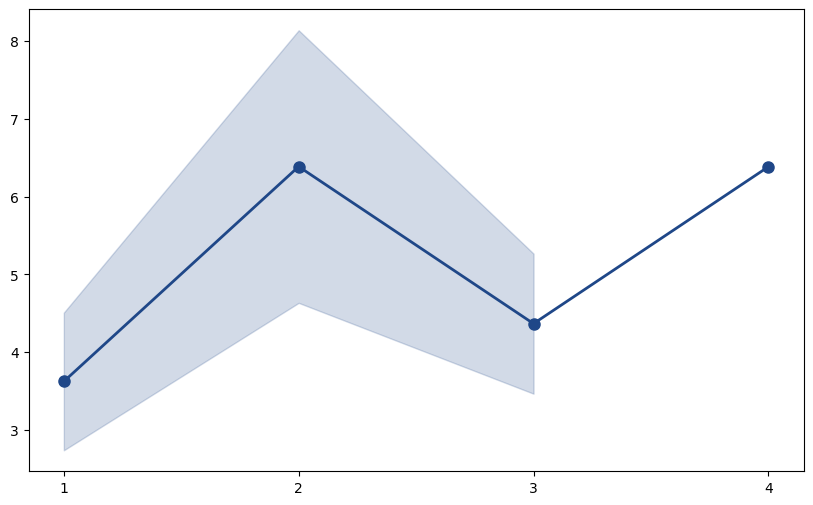


ANALYSIS COMPLETE

Dataframe summary:
  - Total videos: 7
  - Troupes: ['TC-6']
  - Days: ['1', '2', '3', '4']
  - Runs: ['2025_10_14_10_25_19_trial_1_TC', '2025_10_14_14_13_15_trial_1_TC', '2025_10_15_10_09_28_trial_1_TC', '2025_10_15_14_16_21_trial_1_TC', '2025_10_16_09_59_15_trial_1_TC', '2025_10_16_14_12_17_trial_1_TC', '2025_10_17_10_05_03_trial_1_TC']

Files created:
  - Updated KL CSV: /n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/kl_divergence_with_metadata.csv
  - Figures saved to: /n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/figures/

Plot generation complete!


In [4]:
# ============================================================================
# MASTER EXECUTION CELL - Configure and Run Complete Analysis
# ============================================================================

# ----------------------------------------------------------------------------
# CONFIGURATION - Modify these paths and parameters
# ----------------------------------------------------------------------------

# Input file paths
kl_csv_path = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/Tasmanian_Conditioning_KL_Results_COMPILED_2026_02_21_11_30_53.csv'
log_csv_path = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/utils/Planarian_Experiments_Log.csv'

# Output paths
updated_kl_csv_path = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/kl_divergence_with_metadata.csv'
output_dir = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/figures/'

# Analysis parameters
troupe_list = ['TC-2','TC-3','TC-4','TC-5','TC-6','TC-7','TP-1','TP-2','TP-3','TP-4']  # List of all valid troupes
save_figures = False  # Set to False to only display, not save
figure_format = 'png'  # Options: 'png', 'pdf', 'svg'
figure_dpi = 300  # Resolution for saved figures
plot_null = True  # Set to False to hide null distribution on plots
# plot_PC = False # Not yet implemented
# plot_CC = False # Not yet implemeneted



# ----------------------------------------------------------------------------
# EXECUTION - Run the complete pipeline
# ----------------------------------------------------------------------------

print("="*80)
print("STARTING KL DIVERGENCE ANALYSIS PIPELINE")
print("="*80)

# Step 1: Update KL CSV with experimental log information
print("\n[1/4] Updating KL CSV with experimental metadata...")
updated_kl_df = update_kl_with_log_info(
    kl_csv_path=kl_csv_path,
    log_csv_path=log_csv_path,
    output_csv_path=None      # This chunk is not in use, not saving this csv
)

# Step 2: Create worm-specific dataframe
print("\n[2/4] Creating worm-specific KL dataframe...")
worm_kl_df = create_worm_kl_dataframe_from_df(updated_kl_df)
print(f"Created dataframe with {len(worm_kl_df)} videos")
print(f"Columns: {list(worm_kl_df.columns)}")

# Step 3: Generate single plot for KL(CS On||Off)
print("\n[3/4] Generating KL divergence plot across days...")
fig_onoff = plot_troupe_kl_over_days(
    worm_kl_df, 
    troupe_list, 
    plot_null=plot_null,
    figsize=(10, 6)
)

# Optional: Save the figure
save_figures = True
if save_figures:
    os.makedirs(output_dir, exist_ok=True)
    filename = f"kl_onoff_{'_'.join(troupe_list)}.{figure_format}"
    filepath = os.path.join(output_dir, filename)
    fig_onoff.savefig(filepath, dpi=figure_dpi, bbox_inches='tight')
    print(f"Saved KL divergence across days plot to: {filepath}")

plt.show()

# ----------------------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nDataframe summary:")
print(f"  - Total videos: {len(worm_kl_df)}")
print(f"  - Troupes: {sorted(worm_kl_df['Troupe'].unique())}")
print(f"  - Days: {sorted(worm_kl_df['Day'].unique())}")
print(f"  - Runs: {sorted(worm_kl_df['Run'].unique())}")

print(f"\nFiles created:")
print(f"  - Updated KL CSV: {updated_kl_csv_path}")
if save_figures:
    print(f"  - Figures saved to: {output_dir}")

print("\nPlot generation complete!")

# LMM 

In [5]:
# Reshape the dataframe so it's clean. 
print("Creating worm-specific KL dataframe...")
worm_kl_df = create_dataframe_for_LMM(updated_kl_df)

# 1. Identify your ID columns
id_cols = ['Run', 'Troupe', 'Day', 'Block']

# 2. Melt the dataframe so all "W" columns are in one long list
df_melted = pd.melt(worm_kl_df, id_vars=id_cols, var_name='Full_Metric', value_name='Value')

# 3. Split the 'Full_Metric' column (e.g., 'W5_Areas_KL') into 'Subject_ID' and 'Metric'
# We split on the first underscore only
df_split = df_melted['Full_Metric'].str.split('_', n=1, expand=True)
df_melted['Subject_ID'] = df_split[0]
df_melted['Metric'] = df_split[1]

# 4. Pivot the table back so each metric (Areas_KL, etc.) is its own column
df_long = df_melted.pivot_table(
    index=id_cols + ['Subject_ID'], 
    columns='Metric', 
    values='Value',
    aggfunc='first'
).reset_index()

# 5. Clean Subject_ID to be an integer
df_long['Subject_ID'] = df_long['Subject_ID'].str.replace('W', '').astype(int)

print(df_long)

Creating worm-specific KL dataframe...
Metric                             Run Troupe Day Block  Subject_ID  \
0       2025_10_14_10_25_19_trial_1_TC   TC-6   1     1           1   
1       2025_10_14_10_25_19_trial_1_TC   TC-6   1     1           2   
2       2025_10_14_10_25_19_trial_1_TC   TC-6   1     1           3   
3       2025_10_14_10_25_19_trial_1_TC   TC-6   1     1           4   
4       2025_10_14_10_25_19_trial_1_TC   TC-6   1     1           5   
5       2025_10_14_10_25_19_trial_1_TC   TC-6   1     1           6   
6       2025_10_14_14_13_15_trial_1_TC   TC-6   1     2           1   
7       2025_10_14_14_13_15_trial_1_TC   TC-6   1     2           2   
8       2025_10_14_14_13_15_trial_1_TC   TC-6   1     2           3   
9       2025_10_14_14_13_15_trial_1_TC   TC-6   1     2           4   
10      2025_10_14_14_13_15_trial_1_TC   TC-6   1     2           5   
11      2025_10_14_14_13_15_trial_1_TC   TC-6   1     2           6   
12      2025_10_15_10_09_28_trial_1_TC

In [13]:
import statsmodels.formula.api as smf

# Formula: KL_Divergence ~ Trial * Group
# This expands to: KL ~ Trial + Group + (Trial : Group)
#model = smf.mixedlm("KL ~ Day", df_long, groups=df_long["Subject_ID"])

#result = model.fit()
#print(result.summary())

import statsmodels.formula.api as smf
import scipy.stats as stats

# 1. Fit the Full Model (with Day)
# Use 'REML=False' because we are comparing models with different fixed effects
model_full = smf.mixedlm("KL ~ C(Day)", df_long, groups=df_long["Subject_ID"])
result_full = model_full.fit(reml=False)

# 2. Fit the Null Model (without Day)
model_null = smf.mixedlm("KL ~ 1", df_long, groups=df_long["Subject_ID"])
result_null = model_null.fit(reml=False)

# 3. Perform Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_null.llf)
# Calculate the difference in the number of parameters
df_diff = len(result_full.params) - len(result_null.params)

# If df_diff is 0 for some reason (rare), the test isn't valid
if df_diff > 0:
    p_value = stats.chi2.sf(lr_stat, df_diff)
    print(f"Likelihood Ratio Statistic: {lr_stat:.4f}")
    print(f"Degrees of Freedom: {df_diff}")
    print(f"p-value: {p_value:.4f}") # Using scientific notation for small p-values
else:
    print("Error: Models have the same number of parameters. Check your formula.")
    
if p_value > 0.05:
    print("Day is not a significant predictor of KL")

Likelihood Ratio Statistic: 3.6838
Degrees of Freedom: 3
p-value: 0.2977
Day is not a significant predictor of KL
